In [1]:
"""
PCA & DIMENSIONALITY REDUCTION
======================================
Notebook: 04_PCA_Analysis.ipynb
Goal: Reduce 130 features to optimal subset using PCA
Input: X_train_engineered.csv, X_test_engineered.csv
Output: X_train_pca.csv, X_test_pca.csv, pca_model.pkl
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load engineered data from Day 1
X_train = pd.read_csv('X_train_engineered.csv')
X_test = pd.read_csv('X_test_engineered.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"Loaded: X_train {X_train.shape}, X_test {X_test.shape}")

Loaded: X_train (1236125, 130), X_test (624193, 130)


In [2]:
# Drop non-predictive identifier/text columns
identifier_cols = [
    'STRUCTURE_NUMBER_008', 'LOCATION_009', 'FACILITY_CARRIED_007',
    'FEATURES_DESC_006A', 'LRS_INV_ROUTE_013A', 'ROUTE_NUMBER_005D',
    'SUBROUTE_NO_013B', 'OTHR_STATE_STRUC_NO_099'
]

available_ids = [c for c in identifier_cols if c in X_train.columns]
X_train_clean = X_train.drop(columns=available_ids, errors='ignore')
X_test_clean = X_test.drop(columns=available_ids, errors='ignore')

print(f"Removed {len(available_ids)} identifiers: {available_ids}")
print(f"Shape: {X_train.shape[1]} → {X_train_clean.shape[1]} features")

# Scaling interaction features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

X_train_clean = pd.DataFrame(X_train_scaled, columns=X_train_clean.columns, index=X_train_clean.index)
X_test_clean = pd.DataFrame(X_test_scaled, columns=X_test_clean.columns, index=X_test_clean.index)

print("Data standardized (mean=0, std=1)")
print(f"Sample feature means: {X_train_clean.mean().head()}")
print(f"Sample feature stds: {X_train_clean.std().head()}")

Removed 2 identifiers: ['ROUTE_NUMBER_005D', 'SUBROUTE_NO_013B']
Shape: 130 → 128 features
Data standardized (mean=0, std=1)
Sample feature means: FUTURE_ADT_114          -6.815002e-17
ROADWAY_WIDTH_MT_051    -1.747436e-17
PLACE_CODE_004           1.587408e-16
TRAFFIC_DIRECTION_102    8.636015e-17
TOLL_020                -1.434737e-17
dtype: float64
Sample feature stds: FUTURE_ADT_114           1.0
ROADWAY_WIDTH_MT_051     1.0
PLACE_CODE_004           1.0
TRAFFIC_DIRECTION_102    1.0
TOLL_020                 1.0
dtype: float64


In [3]:
# Remove high-variance features that dominate PCA
high_variance_cols = [
    # Cost fields (dollars - huge range)
    'ROADWAY_IMP_COST_095',
    'BRIDGE_IMP_COST_094',
    'TOTAL_IMP_COST_096',
    
    # Date fields (encoded as large numbers)
    'UNDWATER_LAST_DATE_093B',
    'SPEC_LAST_DATE_093C',
    'FRACTURE_LAST_DATE_093A',
    
    # Year/reconstruction (redundant with years_since_reconstruction)
    'YEAR_RECONSTRUCTED_106',
    
    # Navigation clearance (sparse, high variance)
    'NAV_HORR_CLR_MT_040'
]

available_high_var = [c for c in high_variance_cols if c in X_train_clean.columns]
X_train_clean = X_train_clean.drop(columns=available_high_var, errors='ignore')
X_test_clean = X_test_clean.drop(columns=available_high_var, errors='ignore')

print(f"Removed {len(available_high_var)} high-variance features")
print(f"Features remaining: {X_train_clean.shape[1]}")

# Check new variance distribution
new_variances = X_train_clean.var().sort_values(ascending=False)
print(f"\nNew top 10 variances:")
print(new_variances.head(10))
print(f"\nNew median variance: {new_variances.median():.2f}")

Removed 8 high-variance features
Features remaining: 120

New top 10 variances:
PIER_PROTECTION_111        1.000001
has_recent_improvement     1.000001
MEDIAN_CODE_033            1.000001
is_high_traffic            1.000001
MIN_VERT_CLR_010           1.000001
WORK_PROPOSED_075A         1.000001
SPEC_INSPECT_092C          1.000001
STRAHNET_HIGHWAY_100       1.000001
INSPECT_FREQ_MONTHS_091    1.000001
has_modern_design_load     1.000001
dtype: float64

New median variance: 1.00


Components for 90%: 62
Components for 95%: 74
Components for 99%: 92


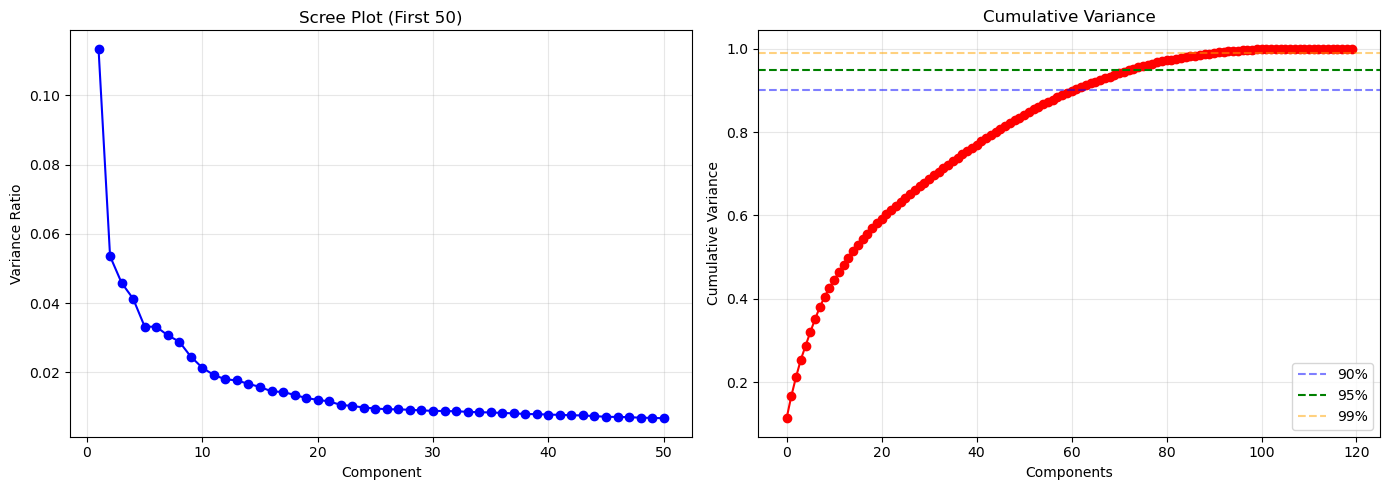

In [4]:
pca_full = PCA()
pca_full.fit(X_train_clean)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 90%: {n_90}")
print(f"Components for 95%: {n_95}")
print(f"Components for 99%: {n_99}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 51), pca_full.explained_variance_ratio_[:50], 'bo-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_title('Scree Plot (First 50)')
axes[0].grid(alpha=0.3)

axes[1].plot(cumulative_variance, 'ro-')
axes[1].axhline(0.90, color='b', linestyle='--', alpha=0.5, label='90%')
axes[1].axhline(0.95, color='g', linestyle='--', label='95%')
axes[1].axhline(0.99, color='orange', linestyle='--', alpha=0.5, label='99%')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
n_components = n_95

pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_clean)
X_test_pca = pca.transform(X_test_clean)

print(f"Reduced: {X_train_clean.shape[1]} → {n_components} components")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Reduction: {(1 - n_components/X_train_clean.shape[1])*100:.1f}%")

pca_cols = [f'PC{i+1}' for i in range(n_components)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

print(f"X_train_pca: {X_train_pca_df.shape}")
print(f"X_test_pca: {X_test_pca_df.shape}")

Reduced: 120 → 74 components
Variance explained: 95.22%
Reduction: 38.3%
X_train_pca: (1236125, 74)
X_test_pca: (624193, 74)


In [6]:
components_df = pd.DataFrame(
    pca.components_[:5],
    columns=X_train_clean.columns,
    index=[f'PC{i+1}' for i in range(min(5, n_components))]
)

print("Top 5 features per component:\n")
for i in range(min(5, n_components)):
    pc = f'PC{i+1}'
    top = components_df.loc[pc].abs().nlargest(5)
    print(f"{pc} ({pca.explained_variance_ratio_[i]:.1%} variance):")
    for feat, val in top.items():
        print(f"  {feat}: {val:.3f}")
    print()

# Aggregate importance
feature_importance = pd.DataFrame({
    'feature': X_train_clean.columns,
    'total_importance': np.abs(components_df).sum(axis=0)
}).sort_values('total_importance', ascending=False)

feature_importance.to_csv('pca_feature_importance.csv', index=False)
print("Top 10 overall important features:")
print(feature_importance.head(10))

Top 5 features per component:

PC1 (11.3% variance):
  log_adt: 0.247
  age_traffic_interaction: 0.247
  traffic_stress_score: 0.238
  ADT_029: 0.209
  HIGHWAY_SYSTEM_104: 0.206

PC2 (5.4% variance):
  DECK_PROTECTION_108C: 0.246
  MEMBRANE_TYPE_108B: 0.245
  RAILINGS_036A: 0.228
  TRANSITIONS_036B: 0.224
  STRUCTURE_TYPE_043B: 0.220

PC3 (4.6% variance):
  YEAR_BUILT_027: 0.261
  bridge_age: 0.261
  DESIGN_LOAD_031: 0.213
  inspection_urgency: 0.198
  needs_very_frequent_inspection: 0.198

PC4 (4.1% variance):
  age_length_interaction: 0.359
  STRUCTURE_LEN_MT_049: 0.359
  DECK_AREA: 0.330
  length_category: 0.309
  is_long_bridge: 0.278

PC5 (3.3% variance):
  YEAR_OF_IMP_097: 0.258
  years_since_improvement: 0.258
  maintenance_burden: 0.253
  has_recent_improvement: 0.241
  OWNER_022: 0.226

Top 10 overall important features:
                                         feature  total_importance
STRUCTURE_LEN_MT_049        STRUCTURE_LEN_MT_049          0.730230
age_length_interaction  

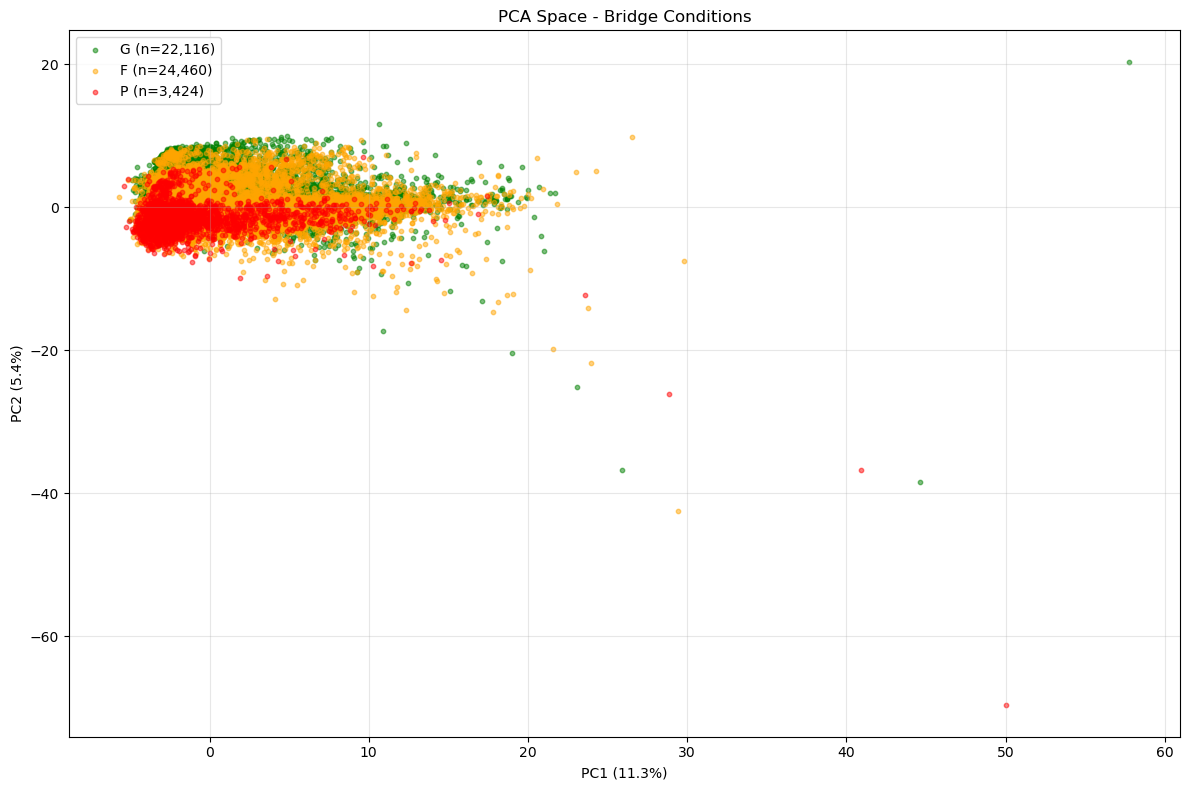


Mean PC1 by class:
  G: 0.13
  F: 0.09
  P: -1.59


In [7]:
sample_size = min(50000, len(X_train_pca))
idx = np.random.choice(len(X_train_pca), sample_size, replace=False)

X_sample = X_train_pca[idx, :2]
y_sample = y_train.iloc[idx]

colors = {'G': 'green', 'F': 'orange', 'P': 'red'}

plt.figure(figsize=(12, 8))
for condition in ['G', 'F', 'P']:
    mask = y_sample == condition
    plt.scatter(X_sample[mask, 0], X_sample[mask, 1],
               c=colors[condition], label=f'{condition} (n={mask.sum():,})',
               alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA Space - Bridge Conditions')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMean PC1 by class:")
for condition in ['G', 'F', 'P']:
    mask = y_sample == condition
    print(f"  {condition}: {X_sample[mask, 0].mean():.2f}")

In [8]:
# Sample 50K rows for clustering (representative, faster - is necessary)
sample_size = 50000
sample_idx = np.random.choice(len(X_train_pca), sample_size, replace=False)
X_sample = X_train_pca[sample_idx]
y_sample = y_train.iloc[sample_idx]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_sample = kmeans.fit_predict(X_sample)

ari = adjusted_rand_score(y_sample, clusters_sample)
silhouette = silhouette_score(X_sample, clusters_sample)

print(f"Adjusted Rand Index: {ari:.3f} (on {sample_size:,} sample)")
print(f"Silhouette Score: {silhouette:.3f}")

crosstab = pd.crosstab(clusters_sample, y_sample, rownames=['Cluster'], colnames=['Actual'])
print("\nCluster vs Actual Condition:")
print(crosstab)

if ari > 0.5:
    print("\nStrong clustering - conditions naturally separate")
elif ari > 0.3:
    print("Moderate clustering - some separation")
else:
    print("Weak clustering - conditions overlap heavily")

print("\nConclusion:")
print("  - Bridge conditions form a continuum, not distinct clusters")
print("  - Supervised learning necessary to capture subtle deterioration patterns")
print("  - PCA components retain predictive information despite weak clustering")

Adjusted Rand Index: -0.004 (on 50,000 sample)
Silhouette Score: 0.140

Cluster vs Actual Condition:
Actual       F      G     P
Cluster                    
0        18432  14296  3115
1         5482   4154   336
2          723   3462     0
Weak clustering - conditions overlap heavily

Conclusion:
  - Bridge conditions form a continuum, not distinct clusters
  - Supervised learning necessary to capture subtle deterioration patterns
  - PCA components retain predictive information despite weak clustering


In [9]:
X_train_pca_df.to_csv('X_train_pca.csv', index=False)
X_test_pca_df.to_csv('X_test_pca.csv', index=False)

with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

with open('pca_log.txt', 'w') as f:
    f.write(f"PCA ANALYSIS\n")
    f.write(f"Original features: {X_train.shape[1]}\n")
    f.write(f"After removing identifiers: {X_train_clean.shape[1]}\n")
    f.write(f"PCA components: {n_components}\n")
    f.write(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}\n")
    f.write(f"Reduction: {(1 - n_components/X_train_clean.shape[1])*100:.1f}%\n")
    f.write(f"Clustering ARI: {ari:.3f}\n")
    f.write(f"Silhouette: {silhouette:.3f}\n")

print("Saved:")
print("  X_train_pca.csv")
print("  X_test_pca.csv")
print("  pca_model.pkl")
print("  pca_feature_importance.csv")
print("  pca_log.txt")

Saved:
  X_train_pca.csv
  X_test_pca.csv
  pca_model.pkl
  pca_feature_importance.csv
  pca_log.txt
